Implement word count /
frequency programs
using MapReduce.

In [ ]:
# Install PySpark
!pip install pyspark

# Import libraries
from pyspark.sql import SparkSession
from pyspark import SparkContext

# Initialize Spark
spark = SparkSession.builder.master("local[*]").appName("WordCount").getOrCreate()
sc = SparkContext.getOrCreate()

# Load file
words_rdd = sc.textFile("/content/sample_data/input.txt")

# Word count pipeline
word_pairs = words_rdd.flatMap(lambda line: line.split(" ")) \
                      .map(lambda word: (word, 1))

# Total word count
total_words = word_pairs.count()
print("\n========== RESULT ==========")
print(f"\nTotal Words: {total_words}")

# Word frequency (reduce)
word_counts = word_pairs.reduceByKey(lambda a, b: a + b)

# Distinct words count
distinct_count = word_counts.count()
print(f"\nDistinct Words: {distinct_count}")

# Sort by frequency
sorted_counts = word_counts.map(lambda x: (x[1], x[0])) \
                           .sortByKey()

# Top 5 words
print("\nTop 5 words:")
for count, word in sorted_counts.top(5):
    print(f"{word} : {count}")

# Top 20 most frequent words
print("\nTop 20 words:")
for count, word in sorted_counts.top(20):
    print(f"{word} : {count}")

# Optional: print all sorted results (nicely formatted)
# print("\nAll words sorted:")
# for count, word in sorted_counts.collect():
#     print(f"{word} : {count}")


========== RESULT ==========

Total Words: 165

Distinct Words: 112

Top 5 words:
and : 9
Python : 9
as : 6
in : 5
was : 4

Top 20 words:
and : 9
Python : 9
as : 6
in : 5
was : 4
is : 4
a : 4
to : 3
the : 3
released : 3
programming : 3
language : 3
its : 3
code : 3
with : 2
on : 2
of : 2
object-oriented : 2
not : 2
write : 1


Pig

In [ ]:
# Install PySpark
!pip install pyspark

# Import required libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("Real Estate Analysis") \
    .getOrCreate()

print("\n========== DATA LOADING ==========\n")

# Load dataset (make sure file is uploaded in Colab)
data = spark.read.option("header", "true") \
                 .csv("/content/sample_data/Real estate (1).csv", inferSchema=True)

# Show schema
print("Schema:\n")
data.printSchema()

# Show sample data
print("\nSample Data:\n")
data.show(10)

print("\n========== FILTERING ==========\n")

# Filter: house age > 20
filtered_data = data.filter(col("X2 house age") > 20)

print("Filtered Data (House Age > 20):\n")
filtered_data.show(10)

print("\n========== GROUPING & ANALYSIS ==========\n")

# Group by convenience stores and calculate average price
grouped_data = filtered_data.groupBy("X4 number of convenience stores") \
    .agg(avg("Y house price of unit area").alias("avg_house_price"))

# Show grouped result
print("Average House Price by Convenience Stores:\n")
grouped_data.show()

print("\n========== COMPLETED ==========\n")

# Stop Spark session
spark.stop()


========== DATA LOADING ==========

Schema:

root
 |-- No: integer (nullable = true)
 |-- X1 transaction date: double (nullable = true)
 |-- X2 house age: double (nullable = true)
 |-- X3 distance to the nearest MRT station: double (nullable = true)
 |-- X4 number of convenience stores: integer (nullable = true)
 |-- X5 latitude: double (nullable = true)
 |-- X6 longitude: double (nullable = true)
 |-- Y house price of unit area: double (nullable = true)


Sample Data:

+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+
| No|X1 transaction date|X2 house age|X3 distance to the nearest MRT station|X4 number of convenience stores|X5 latitude|X6 longitude|Y house price of unit area|
+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+
|  1|           2012.917|        32.0|

Hive

In [ ]:
# =========================================
# INSTALL PYSPARK
# =========================================
!pip install pyspark

# =========================================
# IMPORT LIBRARIES
# =========================================
import os
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import col, avg
from pyspark.sql import Row
from pyspark import SparkContext, SparkConf

# =========================================
# START SPARK WITH HIVE SUPPORT
# =========================================
spark = SparkSession.builder \
    .appName("Spark Hive Example") \
    .enableHiveSupport() \
    .getOrCreate()

sc = SparkContext.getOrCreate()

print("\n========== DATABASE INFO ==========\n")

spark.sql("SHOW DATABASES").show()
spark.sql("SHOW TABLES").show()

# =========================================
# SHOW FUNCTIONS
# =========================================
print("\n========== SAMPLE FUNCTIONS ==========\n")
fncs = spark.sql("SHOW FUNCTIONS").collect()

for i in fncs[100:110]:
    print(i[0])

spark.sql("DESCRIBE FUNCTION instr").show(truncate=False)

# =========================================
# CREATE DATABASE
# =========================================
print("\n========== CREATE DATABASE ==========\n")
spark.sql("CREATE DATABASE IF NOT EXISTS movies")
spark.sql("USE movies")
spark.sql("SHOW DATABASES").show()

# =========================================
# DOWNLOAD DATASET
# =========================================
print("\n========== DOWNLOAD DATA ==========\n")
!wget http://files.grouplens.org/datasets/movielens/ml-latest.zip
!unzip -o /content/ml-latest.zip

# =========================================
# CREATE TABLES
# =========================================
print("\n========== CREATE TABLES ==========\n")

spark.sql("""
CREATE TABLE IF NOT EXISTS movies (
    movieId INT,
    title STRING,
    genres STRING
)
ROW FORMAT DELIMITED
FIELDS TERMINATED BY ','
STORED AS TEXTFILE
""")

spark.sql("""
CREATE TABLE IF NOT EXISTS ratings (
    userId INT,
    movieId INT,
    rating FLOAT,
    timestamp STRING
)
STORED AS ORC
""")

spark.sql("""
CREATE TABLE IF NOT EXISTS genres_by_count (
    genres STRING,
    count INT
)
STORED AS AVRO
""")

spark.sql("SHOW TABLES").show()

# =========================================
# LOAD DATA INTO MOVIES TABLE
# =========================================
print("\n========== LOAD MOVIES DATA ==========\n")

spark.sql("""
LOAD DATA LOCAL INPATH '/content/ml-latest/movies.csv'
OVERWRITE INTO TABLE movies
""")

spark.sql("SELECT * FROM movies LIMIT 10").show(truncate=False)

# =========================================
# READ RATINGS DATA (DATAFRAME)
# =========================================
print("\n========== READ RATINGS ==========\n")

schema = StructType([
    StructField('userId', IntegerType()),
    StructField('movieId', IntegerType()),
    StructField('rating', DoubleType()),
    StructField('timestamp', StringType())
])

ratings_df = spark.read.csv(
    "/content/ml-latest/ratings.csv",
    schema=schema,
    header=True
)

ratings_df.show(5)
ratings_df.printSchema()

# =========================================
# RDD → DATAFRAME METHOD
# =========================================
print("\n========== RDD TO DATAFRAME ==========\n")

rdd = sc.textFile("/content/ml-latest/ratings.csv")
header = rdd.first()

ratings_df2 = rdd.filter(lambda x: x != header) \
    .map(lambda x: Row(
        userId=int(x.split(",")[0]),
        movieId=int(x.split(",")[1]),
        rating=float(x.split(",")[2]),
        timestamp=x.split(",")[3]
    )).toDF()

ratings_df2.show(5)

# =========================================
# ANALYSIS: GENRE COUNT
# =========================================
print("\n========== GENRE ANALYSIS ==========\n")

spark.sql("""
SELECT genres, COUNT(*) AS count
FROM movies
GROUP BY genres
HAVING COUNT(*) > 500
ORDER BY count DESC
""").show()

# =========================================
# INSERT INTO AVRO TABLE
# =========================================
print("\n========== INSERT INTO AVRO TABLE ==========\n")

spark.sql("""
INSERT INTO genres_by_count
SELECT genres, COUNT(*) AS count
FROM movies
GROUP BY genres
HAVING COUNT(*) >= 500
ORDER BY count DESC
""")

spark.sql("""
SELECT * FROM genres_by_count
ORDER BY count DESC
LIMIT 3
""").show()

# =========================================
# TAGS DATAFRAME + TEMP TABLE
# =========================================
print("\n========== TAGS TEMP TABLE ==========\n")

tags_schema = StructType([
    StructField('userId', IntegerType()),
    StructField('movieId', IntegerType()),
    StructField('tag', StringType()),
    StructField('timestamp', StringType())
])

tags_df = spark.read.csv(
    "/content/ml-latest/tags.csv",
    schema=tags_schema,
    header=True
)

tags_df.printSchema()

# Register temp table
tags_df.createOrReplaceTempView("tags_df_table")

spark.sql("SHOW TABLES").show()

# =========================================
# STOP SPARK
# =========================================
print("\n========== COMPLETED ==========\n")
spark.stop()


========== DATABASE INFO ==========

+---------+
|namespace|
+---------+
|  default|
+---------+

+---------+---------+-----------+
|namespace|tableName|isTemporary|
+---------+---------+-----------+
+---------+---------+-----------+


========== SAMPLE FUNCTIONS ==========

contains
conv
convert_timezone
corr
cos
cosh
cot
count
count_if
count_min_sketch
+-----------------------------------------------------------------------------------------------------+
|function_desc                                                                                        |
+-----------------------------------------------------------------------------------------------------+
|Function: instr                                                                                      |
|Class: org.apache.spark.sql.catalyst.expressions.StringInstr                                         |
|Usage: instr(str, substr) - Returns the (1-based) index of the first occurrence of `substr` in `str`.|
+-----------------

Implement Decision tree classification techniques

root
 |-- Pregnancies: integer (nullable = true)
 |-- Glucose: integer (nullable = true)
 |-- BloodPressure: integer (nullable = true)
 |-- SkinThickness: integer (nullable = true)
 |-- Insulin: integer (nullable = true)
 |-- BMI: double (nullable = true)
 |-- DiabetesPedigreeFunction: double (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Outcome: integer (nullable = true)

+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+
|Pregnancies|Glucose|BloodPressure|SkinThickness|Insulin| BMI|DiabetesPedigreeFunction|Age|Outcome|
+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+
|          6|    148|           72|           35|      0|33.6|                   0.627| 50|      1|
|          1|     85|           66|           29|      0|26.6|                   0.351| 31|      0|
|          8|    183|           64|            0|      0|23.3|                   0.672| 32|      1|
|          

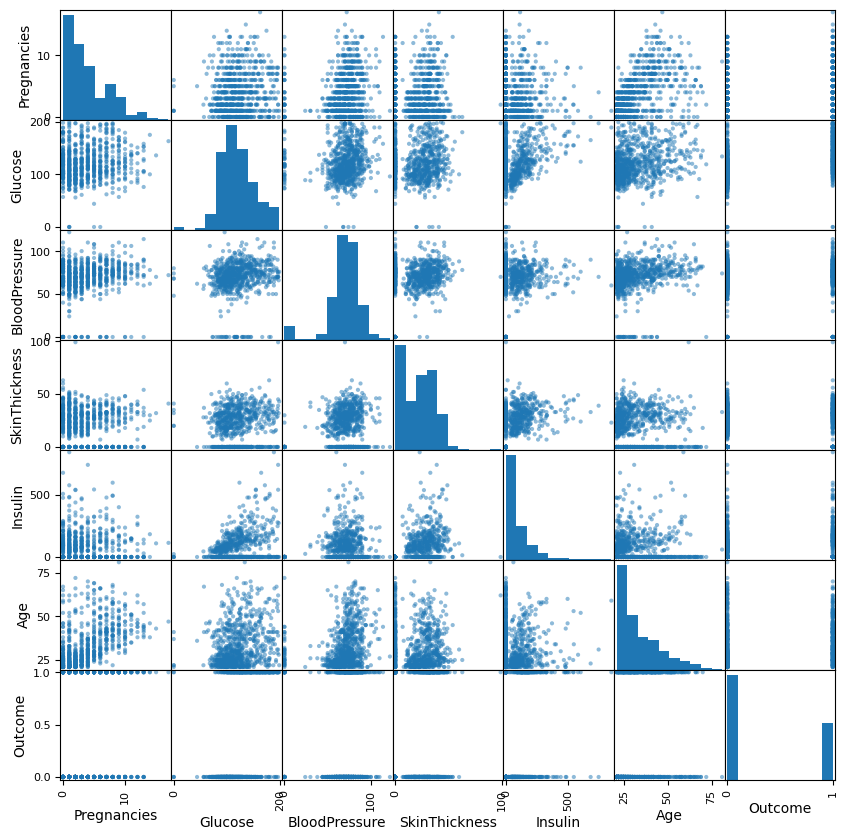

+-----------+-------+-------------+-------------+-------+---+------------------------+---+-------+
|Pregnancies|Glucose|BloodPressure|SkinThickness|Insulin|BMI|DiabetesPedigreeFunction|Age|Outcome|
+-----------+-------+-------------+-------------+-------+---+------------------------+---+-------+
|          0|      0|            0|            0|      0|  0|                       0|  0|      0|
+-----------+-------+-------------+-------------+-------+---+------------------------+---+-------+

+-------+-------------+----+---+-------+
|Glucose|BloodPressure| BMI|Age|Outcome|
+-------+-------------+----+---+-------+
|    148|           72|33.6| 50|      1|
|     85|           66|26.6| 31|      0|
|    183|           64|23.3| 32|      1|
|     89|           66|28.1| 21|      0|
|    137|           40|43.1| 33|      1|
+-------+-------------+----+---+-------+
only showing top 5 rows
+--------------------+-------+
|            features|Outcome|
+--------------------+-------+
|[148.0,72.0,33.6,

In [ ]:
# ================================
# 1. Install PySpark
# ================================
!pip install pyspark

# ================================
# 2. Import Libraries
# ================================
from pyspark.sql import SparkSession
import pandas as pd

# ================================
# 3. Create Spark Session
# ================================
spark = SparkSession.builder.appName('ml-diabetes').getOrCreate()

# ================================
# 4. Load Dataset
# (Upload diabetes.csv manually in Colab first)
# ================================
df = spark.read.csv('/content/sample_data/diabetes.csv', header=True, inferSchema=True)

# ================================
# 5. Basic Info
# ================================
df.printSchema()
df.show(5)

# ================================
# 6. Convert to Pandas (for analysis)
# ================================
pdf = df.toPandas()
print(pdf.head())

# ================================
# 7. GroupBy using Pandas
# ================================
print(pdf.groupby('Outcome').count())

# ================================
# 8. Describe Data
# ================================
numeric_features = [t[0] for t in df.dtypes if t[1] == 'int']

desc = df.select(numeric_features).describe().toPandas()
print(desc.transpose())

# ================================
# 9. Visualization (Pandas)
# ================================
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

numeric_data = df.select(numeric_features).toPandas()
scatter_matrix(numeric_data, figsize=(10,10))
plt.show()

# ================================
# 10. Check Missing Values
# ================================
from pyspark.sql.functions import isnull, when, count

df.select([count(when(isnull(c), c)).alias(c) for c in df.columns]).show()

# ================================
# 11. Feature Selection (Drop columns)
# ================================
dataset = df.drop('SkinThickness').drop('Insulin')
dataset_new = dataset.drop('DiabetesPedigreeFunction')
dataset_final = dataset_new.drop('Pregnancies')

dataset_final.show(5)

# ================================
# 12. Feature Engineering
# ================================
from pyspark.ml.feature import VectorAssembler

required_features = ['Glucose','BloodPressure','BMI','Age']

assembler = VectorAssembler(inputCols=required_features, outputCol='features')
transformed_data = assembler.transform(dataset_final)

transformed_data.select('features','Outcome').show(5)

# ================================
# 13. Train-Test Split
# ================================
(training_data, test_data) = transformed_data.randomSplit([0.8,0.2], seed=2020)

print("Training Count:", training_data.count())
print("Test Count:", test_data.count())

# ================================
# 14. Decision Tree Model
# ================================
from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier(featuresCol='features', labelCol='Outcome', maxDepth=3)
dt_model = dt.fit(training_data)

dt_predictions = dt_model.transform(test_data)

dt_predictions.select('features','Outcome','prediction').show(5)

# ================================
# 15. Evaluate Decision Tree
# ================================
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(labelCol='Outcome', metricName='accuracy')

dt_accuracy = evaluator.evaluate(dt_predictions)
print("Decision Tree Accuracy:", dt_accuracy)

# ================================
# 16. Gradient Boosted Trees
# ================================
from pyspark.ml.classification import GBTClassifier

gb = GBTClassifier(labelCol='Outcome', featuresCol='features')
gb_model = gb.fit(training_data)

gb_predictions = gb_model.transform(test_data)

# ================================
# 17. Evaluate GBT
# ================================
gb_accuracy = evaluator.evaluate(gb_predictions)
print("Gradient Boosted Trees Accuracy:", gb_accuracy)

mplement using Linear_Regression using pyspark

In [ ]:

# =========================================
# ALL-IN-ONE PYSPARK LINEAR REGRESSION CODE
# =========================================

# 1. Install PySpark
!pip install pyspark

# 2. Imports
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression

# 3. Start Spark Session
spark = SparkSession.builder.master("local").appName("linear_regression_model").getOrCreate()

# 4. Load Dataset (UPLOAD 'Real estate.csv' FIRST)
df = spark.read.csv("/content/sample_data/Real estate.csv", header=True, inferSchema=True)

# 5. Show Data
print("Schema:")
df.printSchema()

print("Sample Data:")
df.show(5)

# 6. Summary Statistics
print("Summary:")
df.describe().show()

# 7. Feature Engineering (VectorAssembler)
assembler = VectorAssembler(
    inputCols=[
        'X1 transaction date',
        'X2 house age',
        'X3 distance to the nearest MRT station',
        'X4 number of convenience stores',
        'X5 latitude',
        'X6 longitude'
    ],
    outputCol='features'
)

data = assembler.transform(df)

# Select only features + label
data = data.select('features', 'Y house price of unit area')

print("Features Data:")
data.show(5)

# 8. Train-Test Split
train_data, test_data = data.randomSplit([0.7, 0.3], seed=42)

print("Train Count:", train_data.count())
print("Test Count:", test_data.count())

# 9. Train Model
lr = LinearRegression(
    featuresCol='features',
    labelCol='Y house price of unit area'
)

model = lr.fit(train_data)

# 10. Predictions
predictions = model.transform(test_data)

print("Predictions:")
predictions.select('features', 'Y house price of unit area', 'prediction').show(5)

# 11. Evaluation
results = model.evaluate(test_data)

print("Model Evaluation:")
print("RMSE:", results.rootMeanSquaredError)
print("MSE:", results.meanSquaredError)
print("R2 Score:", results.r2)

# 12. Coefficients
print("Model Coefficients:")
print("Intercept:", model.intercept)
print("Coefficients:", model.coefficients)

print("DONE ✅")



Schema:
root
 |-- No: integer (nullable = true)
 |-- X1 transaction date: double (nullable = true)
 |-- X2 house age: double (nullable = true)
 |-- X3 distance to the nearest MRT station: double (nullable = true)
 |-- X4 number of convenience stores: integer (nullable = true)
 |-- X5 latitude: double (nullable = true)
 |-- X6 longitude: double (nullable = true)
 |-- Y house price of unit area: double (nullable = true)

Sample Data:
+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+
| No|X1 transaction date|X2 house age|X3 distance to the nearest MRT station|X4 number of convenience stores|X5 latitude|X6 longitude|Y house price of unit area|
+---+-------------------+------------+--------------------------------------+-------------------------------+-----------+------------+--------------------------+
|  1|           2012.917|        32.0|                              84.87882| 

Implement using Logistic_Regression using pyspark

In [ ]:
# Install PySpark
!pip install pyspark

# Start Spark Session
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName('ml-diabetes').getOrCreate()

# Load Dataset (Make sure diabetes.csv is uploaded in Colab)
df = spark.read.csv('/content/sample_data/diabetes.csv', header=True, inferSchema=True)

# Show schema and sample data
df.printSchema()
df.show(5)

# Convert small sample to pandas (for visualization)
import pandas as pd
pd.DataFrame(df.take(5), columns=df.columns).transpose()

# Check class distribution
df.groupby('Outcome').count().show()

# Select numeric features
numeric_features = [t[0] for t in df.dtypes if t[1] == 'int']
print("Numeric Features:", numeric_features)

# Statistical summary
df.select(numeric_features).describe().show()

# Check missing values
from pyspark.sql.functions import isnull, when, count

df.select([count(when(isnull(c), c)).alias(c) for c in df.columns]).show()

# Drop unnecessary columns
dataset = df.drop('SkinThickness')
dataset = dataset.drop('Insulin')
dataset = dataset.drop('DiabetesPedigreeFunction')
dataset = dataset.drop('Pregnancies')

dataset.show(5)

# Feature Engineering - Convert into vector
from pyspark.ml.feature import VectorAssembler

required_features = ['Glucose', 'BloodPressure', 'BMI', 'Age']

assembler = VectorAssembler(inputCols=required_features, outputCol='features')
transformed_data = assembler.transform(dataset)

transformed_data.select('features', 'Outcome').show(5)

# Train-Test Split
(training_data, test_data) = transformed_data.randomSplit([0.8, 0.2], seed=2020)

print("Training count:", training_data.count())
print("Test count:", test_data.count())

# Logistic Regression Model
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(featuresCol='features', labelCol='Outcome', maxIter=10)
lrModel = lr.fit(training_data)

# Predictions
predictions = lrModel.transform(test_data)

predictions.select('features', 'Outcome', 'prediction').show(10)

# Model Evaluation
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(labelCol='Outcome', metricName='accuracy')

accuracy = evaluator.evaluate(predictions)

print("✅ Logistic Regression Accuracy:", accuracy)

root
 |-- Pregnancies: integer (nullable = true)
 |-- Glucose: integer (nullable = true)
 |-- BloodPressure: integer (nullable = true)
 |-- SkinThickness: integer (nullable = true)
 |-- Insulin: integer (nullable = true)
 |-- BMI: double (nullable = true)
 |-- DiabetesPedigreeFunction: double (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Outcome: integer (nullable = true)

+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+
|Pregnancies|Glucose|BloodPressure|SkinThickness|Insulin| BMI|DiabetesPedigreeFunction|Age|Outcome|
+-----------+-------+-------------+-------------+-------+----+------------------------+---+-------+
|          6|    148|           72|           35|      0|33.6|                   0.627| 50|      1|
|          1|     85|           66|           29|      0|26.6|                   0.351| 31|      0|
|          8|    183|           64|            0|      0|23.3|                   0.672| 32|      1|
|          

Implement mulitple regression model

In [ ]:
# Install PySpark
!pip install pyspark

# Import Spark
from pyspark.sql import SparkSession

# Create Spark Session
spark = SparkSession.builder.appName('ship_crew_prediction').getOrCreate()

# Load dataset (upload cruise_ship_info.csv first in Colab)
df = spark.read.csv('/content/sample_data/cruise_ship_info.csv', header=True, inferSchema=True)

df.show(10)
df.printSchema()

# Show columns
print(df.columns)

# Convert categorical column (Cruise_line) to numeric
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(inputCol='Cruise_line', outputCol='cruise_cat')
df = indexer.fit(df).transform(df)

df.show(5)

# Feature selection
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        'Age',
        'Tonnage',
        'passengers',
        'length',
        'cabins',
        'passenger_density',
        'cruise_cat'
    ],
    outputCol='features'
)

output = assembler.transform(df)

output.select('features', 'crew').show(5)

# Final dataset
final_data = output.select('features', 'crew')

# Train-test split
train_data, test_data = final_data.randomSplit([0.7, 0.3])

print("Train count:", train_data.count())
print("Test count:", test_data.count())

# Linear Regression model
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(featuresCol='features', labelCol='crew')

model = lr.fit(train_data)

# Evaluate model
training_summary = model.evaluate(train_data)

print("R2 Score:", training_summary.r2)
print("RMSE:", training_summary.rootMeanSquaredError)

# Test model
test_features = test_data.select('features')

predictions = model.transform(test_features)

predictions.show()

+-----------+-----------+---+------------------+----------+------+------+-----------------+----+
|  Ship_name|Cruise_line|Age|           Tonnage|passengers|length|cabins|passenger_density|crew|
+-----------+-----------+---+------------------+----------+------+------+-----------------+----+
|    Journey|    Azamara|  6|30.276999999999997|      6.94|  5.94|  3.55|            42.64|3.55|
|      Quest|    Azamara|  6|30.276999999999997|      6.94|  5.94|  3.55|            42.64|3.55|
|Celebration|   Carnival| 26|            47.262|     14.86|  7.22|  7.43|             31.8| 6.7|
|   Conquest|   Carnival| 11|             110.0|     29.74|  9.53| 14.88|            36.99|19.1|
|    Destiny|   Carnival| 17|           101.353|     26.42|  8.92| 13.21|            38.36|10.0|
|    Ecstasy|   Carnival| 22|            70.367|     20.52|  8.55|  10.2|            34.29| 9.2|
|    Elation|   Carnival| 15|            70.367|     20.52|  8.55|  10.2|            34.29| 9.2|
|    Fantasy|   Carnival| 23| 

text_classification

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (25000,)
Test shape: (25000,)
After padding:
(25000, 200) (25000,)
(25000, 200) (25000,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
100/100 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.7354 - loss: 0.5263 - val_accuracy: 0.8399 - val_loss: 0.3650
Epoch 2/12
100/100 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 0.8848 - loss: 0.2919 - val_accuracy: 0.8612 - val_loss: 0.3230
Epoch 3/12
100/100 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.9232 - loss: 0.2063 - val_accuracy: 0.8704 - val_loss: 0.3219
Epoch 4/12
100/100 ━━━━━━━━━━━━━━━━━━━━ 221s 2s/step - accuracy: 0.9446 - loss: 0.1580 - val_accuracy: 0.8599 - val_loss: 0.3960
Epoch 5/12
100/100 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.9567 - loss: 0.1305 - val_accuracy: 0.8597 - val_loss: 0.3685
Epoch 6/12
100/100 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.9601 - loss: 0.1167 - val_accuracy: 0.8608 - val_loss: 0.4072
Epoch 7/12
100/100 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.9700 - loss: 0.0894 - val_accuracy: 0.8560 - val_loss: 0.4740
Epoch 8/12
100/100 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.9563 - loss: 0.1215 - val_accu

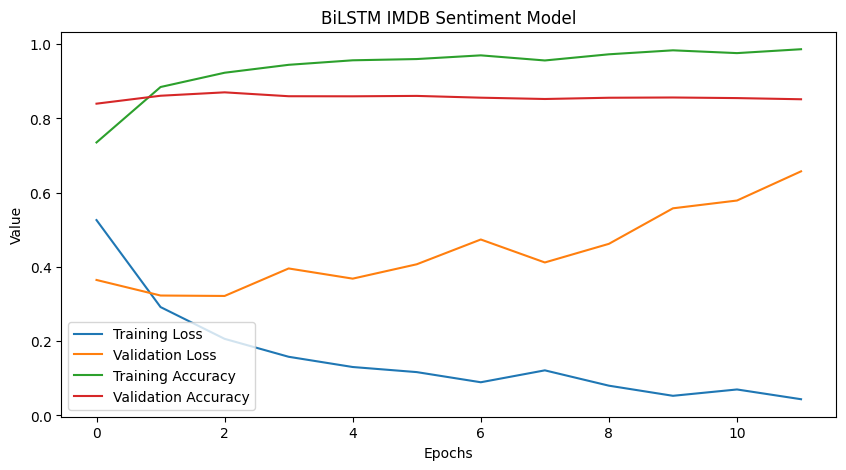

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step

Prediction score: 0.00842419
Sentiment: Negative


In [ ]:
# =========================
# 1. INSTALL / IMPORTS
# =========================
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.layers import Dense, Embedding, LSTM, Bidirectional, Dropout
from tensorflow.keras.datasets import imdb

# =========================
# 2. LOAD DATASET
# =========================
num_words = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

# =========================
# 3. PADDING (FEATURE EXTRACTION)
# =========================
max_len = 200

x_train = sequence.pad_sequences(x_train, maxlen=max_len)
x_test = sequence.pad_sequences(x_test, maxlen=max_len)

y_train = np.array(y_train)
y_test = np.array(y_test)

print("After padding:")
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

# =========================
# 4. BUILD BiLSTM MODEL
# =========================
model = Sequential()

model.add(Embedding(input_dim=num_words, output_dim=128, input_length=max_len))
model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# =========================
# 5. TRAIN MODEL
# =========================
batch_size = 250
epochs = 12

history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    batch_size=batch_size,
    epochs=epochs,
    verbose=1
)

# =========================
# 6. RESULTS
# =========================
print("\nFinal Training Loss:", history.history['loss'][-1])
print("Final Training Accuracy:", history.history['accuracy'][-1])

print("\nFinal Validation Loss:", history.history['val_loss'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

# =========================
# 7. PLOT RESULTS
# =========================
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("BiLSTM IMDB Sentiment Model")
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.legend()
plt.show()

# =========================
# 8. SIMPLE PREDICTION EXAMPLE
# =========================
sample = x_test[0].reshape(1, max_len)
prediction = model.predict(sample)

print("\nPrediction score:", prediction[0][0])
print("Sentiment:", "Positive" if prediction[0][0] > 0.5 else "Negative")

App_User_Segmentatio
n using clustering
method.

In [ ]:
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

pio.templates.default = "plotly_white"

data = pd.read_csv("/content/sample_data/userbehaviour.csv")
print(data.head())

print(f'Average Screen Time = {data["Average Screen Time"].mean()}')
print(f'Highest Screen Time = {data["Average Screen Time"].max()}')
print(f'Lowest Screen Time = {data["Average Screen Time"].min()}')

print(data.describe())

print(f'Average Spend of the Users = {data["Average Spent on App (INR)"].mean()}')
print(f'Highest Spend of the Users = {data["Average Spent on App (INR)"].max()}')
print(f'Lowest Spend of the Users = {data["Average Spent on App (INR)"].min()}')

figure = px.scatter(
    data_frame=data,
    x="Average Screen Time",
    y="Average Spent on App (INR)",
    size="Average Spent on App (INR)",
    color="Status",
    title="Relationship Between Spending Capacity and Screentime",
    trendline="ols"
)
figure.show()

figure = px.scatter(
    data_frame=data,
    x="Average Screen Time",
    y="Ratings",
    size="Ratings",
    color="Status",
    title="Relationship Between Ratings and Screentime",
    trendline="ols"
)
figure.show()

clustering_data = data[[
    "Average Screen Time",
    "Left Review",
    "Ratings",
    "Last Visited Minutes",
    "Average Spent on App (INR)",
    "New Password Request"
]]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(clustering_data)

kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

data["Segments"] = clusters

print(data.head(10))
print(data["Segments"].value_counts())

data["Segments"] = data["Segments"].map({
    0: "Retained",
    1: "Churn",
    2: "Needs Attention"
})

print(data.head(10))

PLOT = go.Figure()

for i in list(data["Segments"].unique()):
    PLOT.add_trace(go.Scatter(
        x=data[data["Segments"] == i]['Last Visited Minutes'],
        y=data[data["Segments"] == i]['Average Spent on App (INR)'],
        mode='markers',
        marker=dict(size=6, line=dict(width=1)),
        name=str(i)
    ))

PLOT.update_traces(
    hovertemplate='Last Visited Minutes: %{x}<br>Average Spent on App (INR): %{y}'
)

PLOT.update_layout(
    width=800,
    height=800,
    autosize=True,
    showlegend=True,
    yaxis_title='Average Spent on App (INR)',
    xaxis_title='Last Visited Minutes'
)

PLOT.show()

   userid  Average Screen Time  Average Spent on App (INR)  Left Review  \
0    1001                 17.0                       634.0            1   
1    1002                  0.0                        54.0            0   
2    1003                 37.0                       207.0            0   
3    1004                 32.0                       445.0            1   
4    1005                 45.0                       427.0            1   

   Ratings  New Password Request  Last Visited Minutes       Status  
0        9                     7                  2990    Installed  
1        4                     8                 24008  Uninstalled  
2        8                     5                   971    Installed  
3        6                     2                   799    Installed  
4        5                     6                  3668    Installed  
Average Screen Time = 24.39039039039039
Highest Screen Time = 50.0
Lowest Screen Time = 0.0
            userid  Average Screen Ti

   userid  Average Screen Time  Average Spent on App (INR)  Left Review  \
0    1001                 17.0                       634.0            1   
1    1002                  0.0                        54.0            0   
2    1003                 37.0                       207.0            0   
3    1004                 32.0                       445.0            1   
4    1005                 45.0                       427.0            1   
5    1006                 28.0                       599.0            0   
6    1007                 49.0                       887.0            1   
7    1008                  8.0                        31.0            0   
8    1009                 28.0                       741.0            1   
9    1010                 28.0                       524.0            1   

   Ratings  New Password Request  Last Visited Minutes       Status  Segments  
0        9                     7                  2990    Installed         1  
1        4    